In [1]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn.neighbors import KernelDensity
from sklearn.cluster import AgglomerativeClustering
from collections import Counter


In [3]:
def r_style_scale(df):
    n = len(df)
    return df / np.sqrt((df ** 2).sum() / (n - 1))

data     = pd.read_csv('chemdiab.csv')
X        = data.iloc[:, :5].astype(float)
X_scaled = r_style_scale(X).to_numpy()
labels   = data['cc'].values

kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_scaled)
projected_data = np.exp(kde.score_samples(X_scaled))

clusterer = AgglomerativeClustering(n_clusters=3, linkage='single')
mapper    = km.KeplerMapper(verbose=0)


In [4]:
import numpy as np
import time

N_SAMPLES = 50
SEED = 42
N_LB, N_UB = 5, 25
OUTPUT_FILE = 'results_output_diabetes_random.txt'

rng = np.random.default_rng(SEED)
n_candidates = rng.integers(N_LB, N_UB + 1, size=N_SAMPLES)
p_candidates = rng.uniform(0.1, 0.7, size=N_SAMPLES)

best_tsc = -np.inf
best_n, best_p, best_iter = None, None, 0

start_time = time.time()
for i, (n_val, p_val) in enumerate(zip(n_candidates, p_candidates)):
    n = int(n_val)
    p = float(p_val)
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=p)
        graph = mapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover)
        tsc = evaluate.compute_SC_adj(X_scaled, projected_data, graph, cover, type='k', cluster=clusterer)
    except Exception:
        tsc = 0.0
    if tsc > best_tsc:
        best_tsc = tsc
        best_n, best_p, best_iter = n, p, i
total_time = time.time() - start_time
convergence_time = total_time * (best_iter + 1) / N_SAMPLES

with open(OUTPUT_FILE, 'a') as f:
    f.write("=== Random-Mapper ===\n")
    f.write(f"Best n: {best_n}\n")
    f.write(f"Best a: {round(best_p, 3)}\n")
    f.write(f"Best TSC: {round(best_tsc, 4)}\n")
    f.write(f"Convergence iteration: {best_iter}\n")
    f.write(f"Convergence time: {convergence_time:.4f}s\n")
    f.write(f"Total time: {total_time:.4f}s\n\n")

print(f"Best N={best_n}, p={round(best_p, 3)}, TSC={round(best_tsc, 4)}")
print(f"Found at iteration {best_iter}, convergence_time={convergence_time:.4f}s, total={total_time:.4f}s")


100%|██████████| 100/100 [00:00<00:00, 510.86it/s]


SC:-0.008634803400119717
SC_norm:0.49568259829994016
TSR:0.0
SC_adj:0.24784129914997008


100%|██████████| 100/100 [00:00<00:00, 311.67it/s]


SC:-0.2172186378825126
SC_norm:0.3913906810587437
TSR:0.07692307692307693
SC_adj:0.2341568789909103


100%|██████████| 100/100 [00:00<00:00, 420.95it/s]


...

SC:-0.2864067048636518
SC_norm:0.3567966475681741
TSR:0.018518518518518517
SC_adj:0.1876575830433463


100%|██████████| 100/100 [00:00<00:00, 284.20it/s]


SC:-0.12496972272464515
SC_norm:0.43751513863767744
TSR:0.034482758620689655
SC_adj:0.23599894862918355


100%|██████████| 100/100 [00:00<00:00, 405.47it/s]

SC:-0.08721377665628637
SC_norm:0.4563931116718568
TSR:0.03125
SC_adj:0.2438215558359284
Best N=6, p=0.501, TSC=0.3055
Found at iteration 35, convergence_time=10.6117s, total=14.7384s


# Random-Mapper — Final Graph

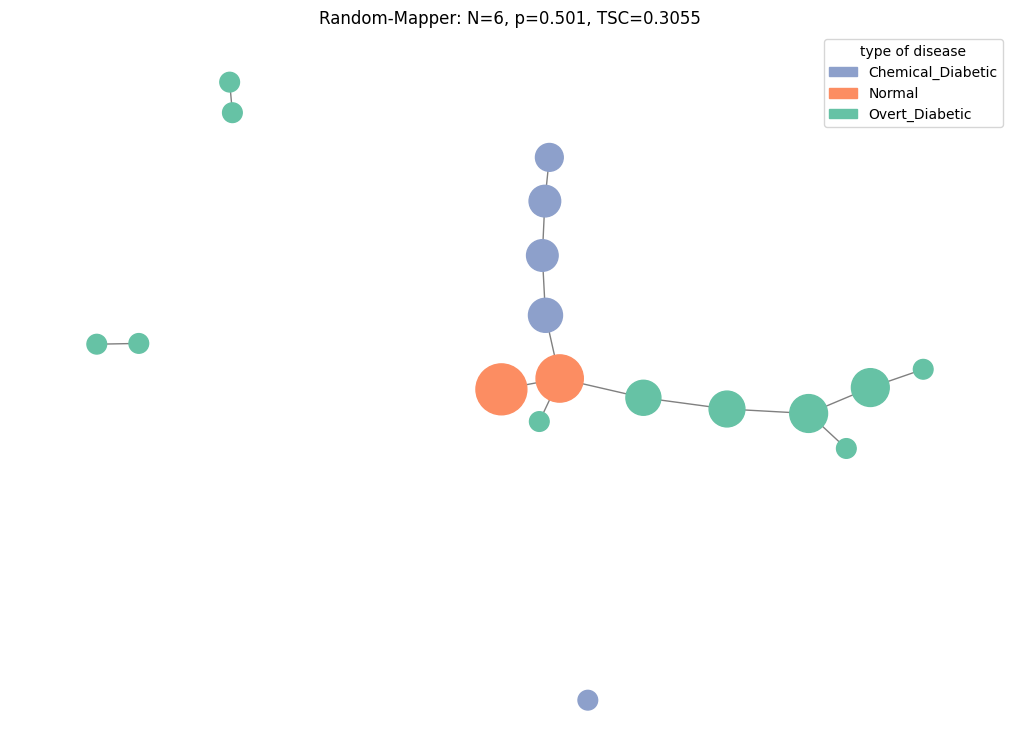

100%|██████████| 100/100 [00:00<00:00, 441.91it/s]

SC:-0.06378819339718607
SC_norm:0.46810590330140694
TSR:0.14285714285714285
SC_adj:0.3054815230792749


0.3054815230792749

In [5]:
fixed_color_map = {
    'Normal':            '#fc8d62',
    'Chemical_Diabetic': '#8da0cb',
    'Overt_Diabetic':    '#66c2a5',
}

def mode(lst):
    return Counter(lst).most_common(1)[0][0]

cover = km.Cover(n_cubes=best_n, perc_overlap=best_p)
graph = mapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover)

G = km.adapter.to_networkx(graph)
node_colors = [fixed_color_map[mode(labels[list(graph['nodes'][v])])] for v in G.nodes]
node_sizes  = [np.log2(len(graph['nodes'][v]) + 1) * 200 for v in G.nodes]
plt.figure(figsize=(10, 7))
nx.draw(G, node_color=node_colors, node_size=node_sizes, edge_color='gray', with_labels=False)
patches = [mpatches.Patch(color=fixed_color_map[l], label=l) for l in sorted(fixed_color_map)]
plt.legend(handles=patches, title='type of disease')
plt.title(f"Random-Mapper: N={best_n}, p={round(best_p,3)}, TSC={round(best_tsc,4)}")
plt.savefig('random_mapper_diabetes.png', bbox_inches='tight')
plt.show()

evaluate.compute_SC_adj(X_scaled, projected_data, graph, cover, type='k', cluster=clusterer)
